In [4]:
from sklearn.datasets import make_blobs
import pandas as pd

X, _ = make_blobs(n_samples=1000000, n_features=10, centers=20, random_state=42)
pd.DataFrame(X).to_csv("data.csv", header=False, index=False)


In [5]:
!ls -lh data.csv

-rw-r--r--@ 1 yoavfreund  staff   179M Jul 21 12:59 data.csv


In [24]:
import dask.dataframe as dd
import pandas as pd
from sklearn.cluster import MiniBatchKMeans

# Parameters
filename = '../../Voltage_Data/glove/glove_with_pos_label.csv'
chunk_size = 2000
n_clusters = 1000

# Create Dask DataFrame (assumes no headers)
dask_df = dd.read_csv(filename, header=None, blocksize=chunk_size * 8 * 300)  # approx chunk_size rows of float64

# Initialize MiniBatchKMeans
mbk = MiniBatchKMeans(n_clusters=n_clusters, batch_size=chunk_size, init='k-means++', random_state=42)

# Stream through partitions (each partition ~ chunk_size rows)
for i, partition in enumerate(dask_df.partitions):
    # Compute the partition (brings chunk into memory)
    df_raw = partition.compute()
    if df_raw.shape[0]<n_clusters:
        print(f"Warning: Partition {i} has fewer rows than n_clusters ({df_raw.shape[0]} < {n_clusters}). Skipping.")
        continue
    
    # Drop NaNs just in case
    df_raw.dropna(inplace=True)

    df_chunk = df_raw.iloc[1:, 1:301]
    if not df_chunk.empty:
        mbk.partial_fit(df_chunk.values)
        print(f"Chunk {i}: Trained on {len(df_chunk)} samples")

# Final centroids
print("Final cluster centers shape:", mbk.cluster_centers_.shape)


Chunk 0: Trained on 1843 samples
Chunk 1: Trained on 1842 samples
Chunk 2: Trained on 1842 samples
Chunk 3: Trained on 1843 samples
Chunk 4: Trained on 1842 samples
Chunk 5: Trained on 1842 samples
Chunk 6: Trained on 1843 samples
Chunk 7: Trained on 1842 samples
Chunk 8: Trained on 1843 samples
Chunk 9: Trained on 1842 samples
Chunk 10: Trained on 1842 samples
Chunk 11: Trained on 1843 samples
Chunk 12: Trained on 1843 samples
Chunk 13: Trained on 1842 samples
Chunk 14: Trained on 1842 samples
Chunk 15: Trained on 1843 samples
Chunk 16: Trained on 1841 samples
Chunk 17: Trained on 1842 samples
Chunk 18: Trained on 1842 samples
Chunk 19: Trained on 1843 samples
Chunk 20: Trained on 1842 samples
Chunk 21: Trained on 1843 samples
Chunk 22: Trained on 1842 samples
Chunk 23: Trained on 1842 samples
Chunk 24: Trained on 1843 samples
Chunk 25: Trained on 1842 samples
Chunk 26: Trained on 1843 samples
Chunk 27: Trained on 1842 samples
Chunk 28: Trained on 1842 samples
Chunk 29: Trained on 184

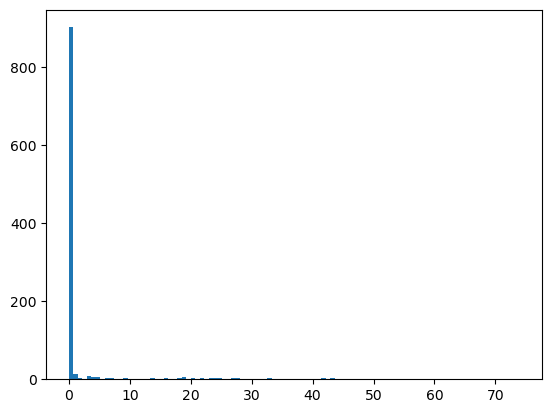

In [26]:
import numpy as np

# Predict cluster labels for the final chunk
labels = mbk.predict(df_chunk.values)

# Count points per cluster (array of length n_clusters)
counts = np.bincount(labels, minlength=mbk.n_clusters)

from matplotlib import pyplot as plt
plt.hist(counts,bins=100);


In [27]:
counts[:10]

array([ 0,  0,  0,  0,  0,  0,  0,  0, 24,  5])